# 📌 NOTE CHỤP HÌNH CHO BÁO CÁO
Các ghi chú có biểu tượng **📸 CHÈN HÌNH BÁO CÁO** đã được đặt trực tiếp ngay trên cell cần chụp. Dùng `Ctrl+F` và tìm cụm **CHÈN HÌNH BÁO CÁO** để nhảy nhanh giữa các vị trí.


In [1]:
from pathlib import Path
import os, sys

PROJECT_ROOT = Path.cwd().resolve()
if not ((PROJECT_ROOT / 'utils').exists() and (PROJECT_ROOT / 'models').exists()):
    for candidate in PROJECT_ROOT.parents:
        if (candidate / 'utils').exists() and (candidate / 'models').exists():
            PROJECT_ROOT = candidate
            break
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from utils.model_manager import generate_report


In [3]:
# Đọc metrics do các notebook 04–07 lưu trong thư mục models.
model_dir = PROJECT_ROOT / 'models'
print('Thư mục kết quả:', model_dir)


Thư mục kết quả: /mnt/data/Practice_2_FIXED_RUNNABLE/models


---
> 📸 **HÌNH 35 — CHÈN HÌNH BÁO CÁO [08-MODEL-COMPARISON-01] — Mục 6.2 – So sánh toàn bộ mô hình**  
> Chụp bảng output R², MAE, RMSE và MAPE của Linear Regression, Decision Tree, Random Forest và LightGBM. Chỉ chụp sau khi đã chạy lại đồng bộ notebook 03→08.  
> **Vị trí:** cell code nằm **ngay bên dưới ghi chú này**.
---

BẢNG SO SÁNH MÔ HÌNH TRÊN TẬP TEST


,Mô hình,Target,R2,MAE,RMSE,MAPE,Tham số tốt nhất,File mô hình
0,linear_regression_scratch,log1p(Total Amount),0.6076,202.51,338.92,56.02,"learning_rate=0.1, epochs=1000",linear_regression_scratch.pkl
1,decision_tree_scratch,log1p(Total Amount),0.7172,181.87,287.74,52.75,"max_depth=3, min_samples_split=100, min_samples_leaf=100",decision_tree_scratch.pkl
2,random_forest_scratch,Total Amount gốc,0.5699,206.49,354.83,70.41,"n_estimators=20, max_depth=6, min_samples_split=50, min_samples_leaf=25",random_forest_scratch.pkl
3,model_lightgbm_scratch,log1p(Total Amount),0.6228,200.04,332.28,54.25,"n_estimators=20, learning_rate=0.1, max_depth=3",model_lightgbm_scratch.pkl


Mô hình có R² cao nhất: decision_tree_scratch (R² = 0.7172)


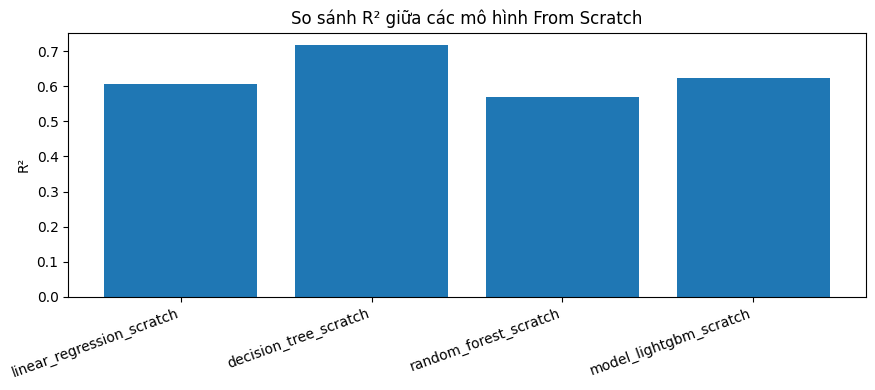

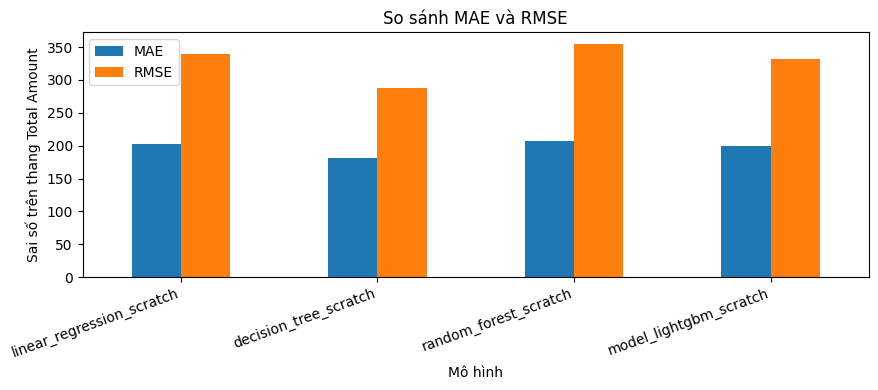

In [4]:
pd.set_option('display.max_colwidth', None)
report_df = generate_report(model_dir=model_dir)

if report_df.empty:
    raise RuntimeError('Chưa có metrics. Hãy chạy notebook 04, 05, 06 và 07 trước notebook 08.')

cols = ['Mô hình', 'Target', 'R2', 'MAE', 'RMSE', 'MAPE', 'Tham số tốt nhất', 'File mô hình']
report_df = report_df[[c for c in cols if c in report_df.columns]]
print('BẢNG SO SÁNH MÔ HÌNH TRÊN TẬP TEST')
display(report_df.round({'R2': 4, 'MAE': 2, 'RMSE': 2, 'MAPE': 2}))

best_idx = report_df['R2'].astype(float).idxmax()
print(f"Mô hình có R² cao nhất: {report_df.loc[best_idx, 'Mô hình']} "
      f"(R² = {report_df.loc[best_idx, 'R2']:.4f})")

plt.figure(figsize=(9, 4))
plt.bar(report_df['Mô hình'], report_df['R2'])
plt.ylabel('R²')
plt.title('So sánh R² giữa các mô hình From Scratch')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

error_df = report_df.set_index('Mô hình')[['MAE', 'RMSE']].astype(float)
error_df.plot(kind='bar', figsize=(9, 4))
plt.ylabel('Sai số trên thang Total Amount')
plt.title('So sánh MAE và RMSE')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()
